# The interactive terminal viewer

Added in v16.35.0. `meshioplusplus tui` (and `mp.tui`, and `view(backend="terminal")`) lets you orbit, zoom and pan a mesh **inside the terminal you are in**: no display, GPU, browser or X forwarding. It is the viewer for an SSH session or a container shell. See `doc/tui.md`.

A notebook is not a terminal, so this notebook cannot take one over. Instead it *replays* a recorded session: the same loop, fed a recorded stream of mouse and key events on a screen of a stated size. That is how the viewer's tests and the documentation screenshots are made, and the result is reproducible byte for byte.

In [1]:
import os
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv
from IPython.display import HTML, display

os.environ.setdefault('MESHIOPLUSPLUS_LOG_LEVEL', 'error')
import meshioplusplus as mp  # noqa: E402

pv.OFF_SCREEN = True
pv.set_jupyter_backend('static')
TMP = tempfile.mkdtemp()

bunny = mp.read(os.path.join(os.path.dirname(os.getcwd()), 'Bunny.stl'))
bunny = mp.Mesh(bunny.points, bunny.cells, point_data={'height': bunny.points[:, 2].copy()})
print(len(bunny.points), 'points,', sum(len(c.data) for c in bunny.cells), 'triangles')

56203 points, 112402 triangles


## A recorded session

Mouse events arrive as SGR reports, `ESC [ < button ; column ; row M` (press or drag) and `m` (release); a key is its byte. Here: press at column 40, row 14, drag to column 47, row 12 (a drag across the whole 100-column width turns the camera 360 degrees), release, then two wheel clicks (button code 64 is the wheel up) and the `3` key for the `-x` view.

In [2]:
def mouse(code, x, y, release=False):
    return f'\x1b[<{code};{x};{y}{"m" if release else "M"}'.encode()


script = (
    mouse(0, 40, 14) + mouse(32, 44, 13) + mouse(32, 47, 12) + mouse(0, 47, 12, release=True)
    + mouse(64, 47, 12) + mouse(64, 47, 12)
)
options = dict(color_by='height', cmap='viridis', colorbar=True, shading='smooth')

result = mp.tui(bunny, replay=script, cols=100, rows=34, color_depth='truecolor', title='bunny.stl', **options)
print({k: (round(v, 2) if isinstance(v, float) else v) for k, v in result.items() if k != 'output'})
print(len(result['output']), 'bytes written for', result['frames'], 'frames')

{'exit': 0, 'frames': 2, 'status': ' bunny.stl  az 20  el 24  zoom 1.21  ortho  | ? help  q quit', 'azimuth': 19.8, 'elevation': 23.65, 'zoom': 1.21, 'pan_x': 0.0, 'pan_y': 0.0}
42564 bytes written for 2 frames


The viewer started at the isometric view (azimuth 45, elevation 35) and the drag moved the camera; the two wheel clicks zoomed in by 1.1 each. `result["output"]` is everything the loop wrote: cursor moves, colours and block glyphs. The first frame is the whole picture; after that only the cells that changed are written, so a small change (the axes appearing) costs a small update, while a drag that moves the whole picture rewrites most of it (the status line, in reverse video, ends each frame):

In [3]:
def frame_sizes(output):
    return [len(chunk) for chunk in output.split(b'\x1b[7m')]


axes_on = mp.tui(bunny, replay=b'a', cols=100, rows=34, color_depth='truecolor', **options)
start, after_axes = frame_sizes(axes_on['output'])[:2]
after_drag = frame_sizes(result['output'])[1]
print(f'first frame, every cell : {start:6d} bytes')
print(f'after toggling the axes: {after_axes:6d} bytes')
print(f'after the whole drag    : {after_drag:6d} bytes (most of the picture changed)')

first frame, every cell :  18212 bytes
after toggling the axes:    346 bytes
after the whole drag    :  24236 bytes (most of the picture changed)


## The camera, as pictures

The same camera direction through `render_image`, beside what PyVista draws from the same viewpoint (without the viewer's zoom). The viewer fits the *bounding sphere* of the model rather than its projected extent, so it keeps one size while it turns; `render_image` fits the extent, so the sizes differ slightly.

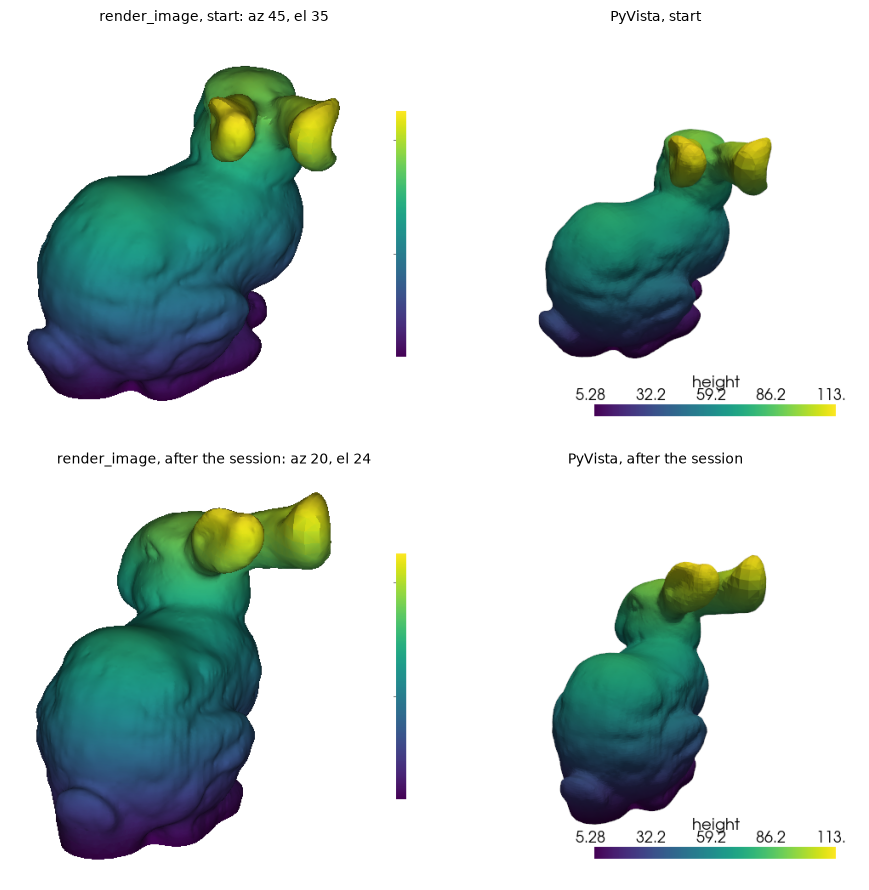

In [4]:
def pyvista_panel(mesh, ax, title, azimuth, elevation, **kwargs):
    try:
        target = os.path.join(TMP, 'render.vtu')
        mp.write(target, mesh)
        pl = pv.Plotter(off_screen=True, window_size=(480, 480))
        pl.add_mesh(pv.read(target), **kwargs)
        az, el = np.radians(azimuth), np.radians(elevation)
        pl.view_vector((np.cos(el) * np.cos(az), np.cos(el) * np.sin(az), np.sin(el)), viewup=(0, 0, 1))
        pl.reset_camera()
        ax.imshow(pl.screenshot(return_img=True))
        pl.close()
    except Exception as exc:  # head-less GL fallback
        print('PyVista render skipped:', exc)
        ax.scatter(bunny.points[::50, 0], bunny.points[::50, 1], s=1)
    ax.set_title(title, fontsize=10)
    ax.axis('off')


fig, axes = plt.subplots(2, 2, figsize=(9, 9))
for row, (name, az, el, zoom) in enumerate([('start', 45.0, 35.26, 1.0), ('after the session', result['azimuth'], result['elevation'], result['zoom'])]):
    image = mp.render_image(bunny, 480, 480, azimuth=az, elevation=el, zoom=1.0, **options)
    axes[row, 0].imshow(image)
    axes[row, 0].set_title(f'render_image, {name}: az {az:.0f}, el {el:.0f}', fontsize=10)
    axes[row, 0].axis('off')
    pyvista_panel(bunny, axes[row, 1], f'PyVista, {name}', az, el, scalars='height', cmap='viridis')
plt.tight_layout()
plt.show()

## The same screen as text

What the loop shows at the end of the session is the same frame as `render_text` draws for that camera, as text for a terminal or as HTML:

In [5]:
page = mp.render_text(
    bunny, cols=100, rows=30, format='html', azimuth=result['azimuth'], elevation=result['elevation'],
    zoom=result['zoom'], **options,
)
display(HTML(page))

## Keys

| input | does |
| --- | --- |
| drag (left button) | orbit |
| drag (right button) or shift-drag, arrow keys | pan |
| wheel, `+` `-`, Page Up / Down | zoom |
| `1` .. `7` | the views `iso`, `+x`, `-x`, `+y`, `-y`, `+z`, `-z` |
| `p`, `e`, `s` | perspective, edges, shading |
| `a`, `b`, `c` | axes, scale bar, colour bar |
| `r`, `?`, `q` | reset, help, quit |

On a real terminal you would call `mp.tui(mesh)` or run `meshioplusplus tui part.vtu`. The terminal is restored however the viewer ends, including on `SIGINT`, `SIGTERM` and `SIGHUP`, and on a non-terminal it stops with a message pointing at `snapshot`.

## `view()` and the terminal

`view(mesh)` picks a backend by itself: polyscope when it is installed and a display exists, the browser when a display exists, **the terminal viewer when only a terminal is left**, and the browser's HTML file otherwise (as in this notebook, which is not a terminal). Ask for one explicitly with `backend='polyscope'`, `'browser'` or `'terminal'`.